In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

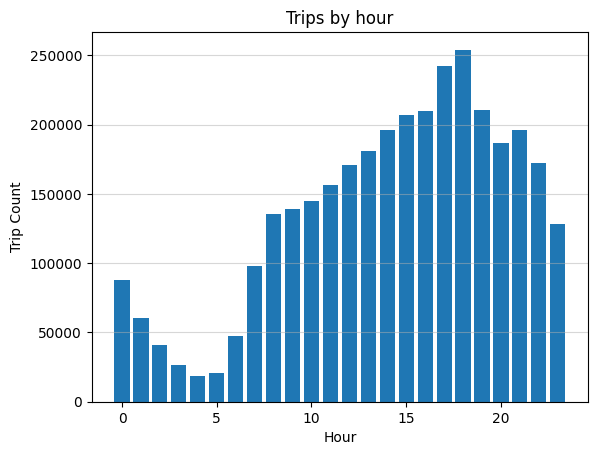

In [85]:
#trips by hour

trip_hour = pd.read_parquet('../data/marts/mart_hourly_demand.parquet').reset_index()

plt.Figure(figsize = (10,5))
plt.title('Trips by hour')

plt.bar(trip_hour['pickup_hour'],trip_hour['trip_count'])

plt.grid(True, alpha = 0.5, axis = 'y')
plt.xlabel('Hour')
plt.ylabel('Trip Count')
plt.xticks()
plt.show()


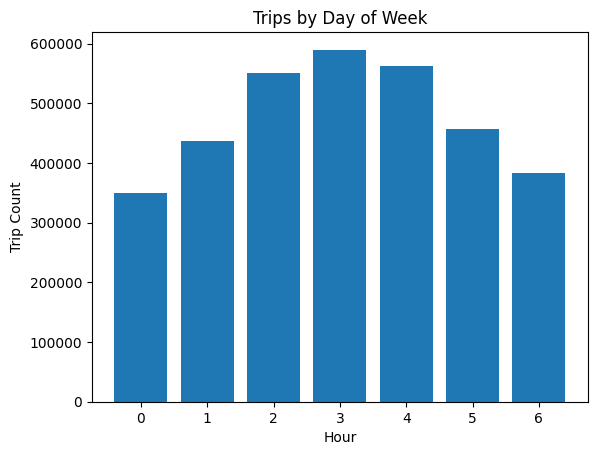

In [ ]:
#trips by day

daily_trip = pd.read_parquet('../data/marts/mart_daily_demand.parquet').reset_index()

plt.Figure(figsize = (10,5))
plt.title('Trips by Day of Week')

plt.bar(daily_trip['pickup_dayofw'],daily_trip['trip_count'])

plt.xlabel('Hour')
plt.ylabel('Trip Count')
plt.xticks()
plt.show()



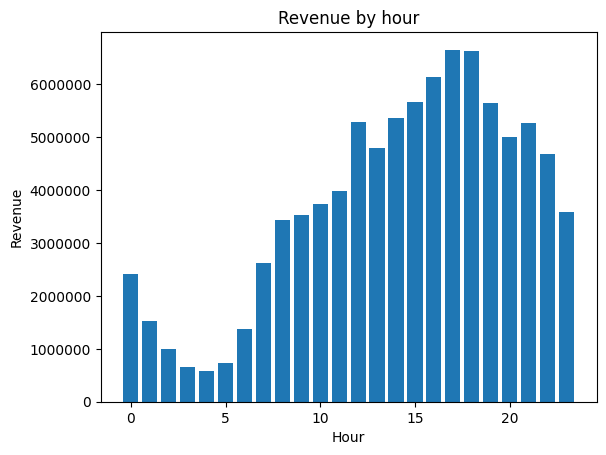

In [27]:
#Revenue by hour

revenue_hour = pd.read_parquet('../data/marts/mart_hourly_demand.parquet').reset_index()

plt.Figure(figsize = (10,5))
plt.title('Revenue by hour')

plt.bar(trip_hour['pickup_hour'],trip_hour['revenue'])

plt.xlabel('Hour')
plt.ylabel('Revenue')
plt.ticklabel_format(style = 'plain',axis = 'y')
plt.xticks()
plt.show()

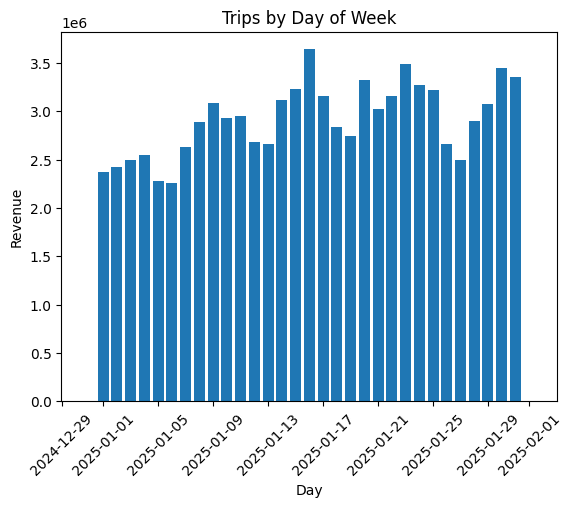

In [37]:
#Revenue by day

df = pd.read_parquet('../data/processed/clean_yellow_2025-01.parquet')

revenue_day = (
    df.groupby('pickup_date')
    .agg(
        total_passenger = ('passenger_count','sum'),
        trip_count = ('tpep_pickup_datetime','count'),
        avg_trip_distance =('trip_distance','mean'),
        revenue= ("total_amount","sum"),
        avg_tip_rate = ('tip_rate','mean'),
        avg_duration = ('duration_mins','mean')
    )
    .sort_values('pickup_date', ascending = False)
    .reset_index()
)
revenue_day['avg_tip_rate'] = revenue_day['avg_tip_rate'] * 100
plt.Figure(figsize = (10,5))
plt.title('Trips by Day of Week')

plt.bar(revenue_day['pickup_date'],revenue_day['revenue'])

plt.xlabel('Day')
plt.ylabel('Revenue')
plt.xticks(rotation = 45)
plt.show()

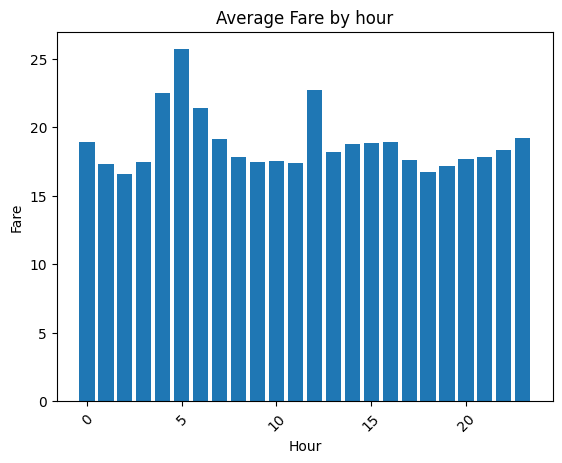

In [40]:
#Average fare by hour

Avg_fare_hour = (
    df.groupby('pickup_hour')
    .agg(
        avg_fare = ('fare_amount','mean')
    )
    .sort_values('pickup_hour', ascending = False)
    .reset_index()
)
plt.Figure(figsize = (10,5))
plt.title('Average Fare by hour')

plt.bar(Avg_fare_hour ['pickup_hour'],Avg_fare_hour ['avg_fare'])

plt.xlabel('Hour')
plt.ylabel('Fare')
plt.xticks(rotation = 45)
plt.show()

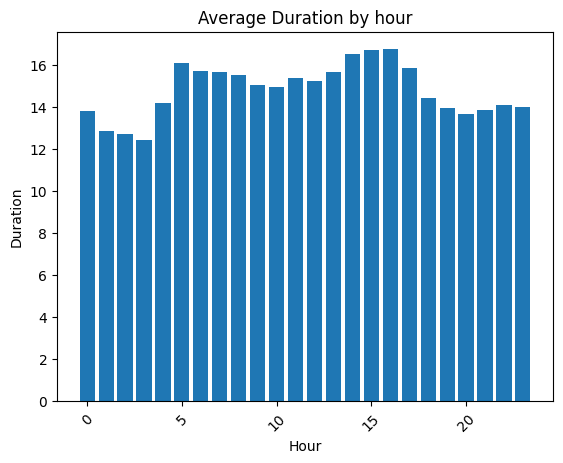

In [41]:
#Average duration by hour

avg_duration_hour = (
    df.groupby('pickup_hour')
    .agg(
        avg_duration = ('duration_mins','mean')
    )
    .sort_values('pickup_hour', ascending = False)
    .reset_index()
)
plt.Figure(figsize = (10,5))
plt.title('Average Duration by hour')

plt.bar(avg_duration_hour ['pickup_hour'],avg_duration_hour ['avg_duration'])

plt.xlabel('Hour')
plt.ylabel('Duration')
plt.xticks(rotation = 45)
plt.show()

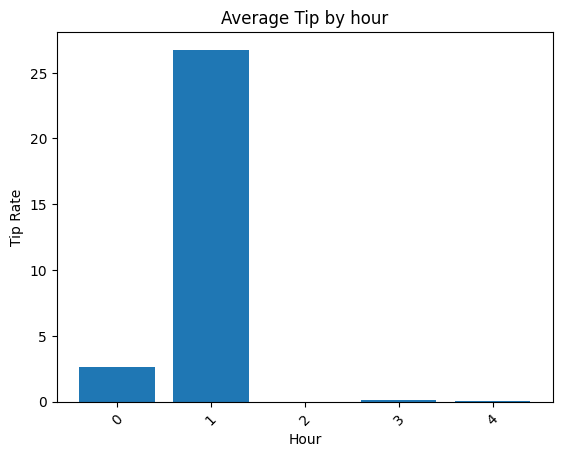

In [86]:
#Tip rate by payment

tip_payment =  pd.read_parquet('../data/marts/mart_tip_behavior.parquet').reset_index()
plt.Figure(figsize = (10,5))
plt.title('Average Tip by hour')

plt.bar(tip_payment['payment_type'],tip_payment ['avg_tip_rate'])

plt.xlabel('Hour')
plt.ylabel('Tip Rate')
plt.xticks(rotation = 45)
plt.show()

   LocationID        Borough                     Zone service_zone
0           1            EWR           Newark Airport          EWR
1           2         Queens              Jamaica Bay    Boro Zone
2           3          Bronx  Allerton/Pelham Gardens    Boro Zone
3           4      Manhattan            Alphabet City  Yellow Zone
4           5  Staten Island            Arden Heights    Boro Zone


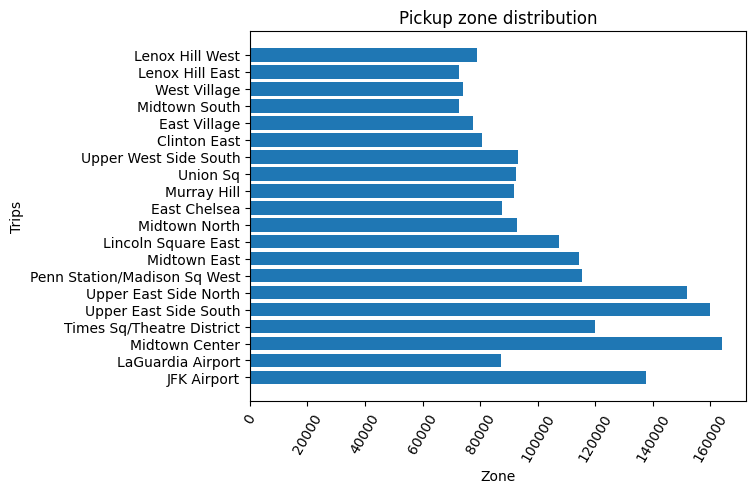

In [56]:
#Top pick up zones

pickup_demand=  pd.read_parquet('../data/marts/mart_pickup_demand.parquet').reset_index().head(20)
taxi_zone = pd.read_csv('../data/raw/taxi_zone_lookup.csv')

print(taxi_zone.head())

pickup_demand = pickup_demand.merge(
    taxi_zone[['LocationID','Zone']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
).rename(columns = {'Zone':'pickup_zone'}).drop(columns=['LocationID'])

plt.Figure(figsize = (10,5))
plt.title('Pickup zone distribution')

plt.barh(pickup_demand['pickup_zone'].astype(str),pickup_demand ['trip_count'])

plt.xlabel('Zone')
plt.ylabel('Trips')
plt.xticks(rotation = 60)
plt.show()

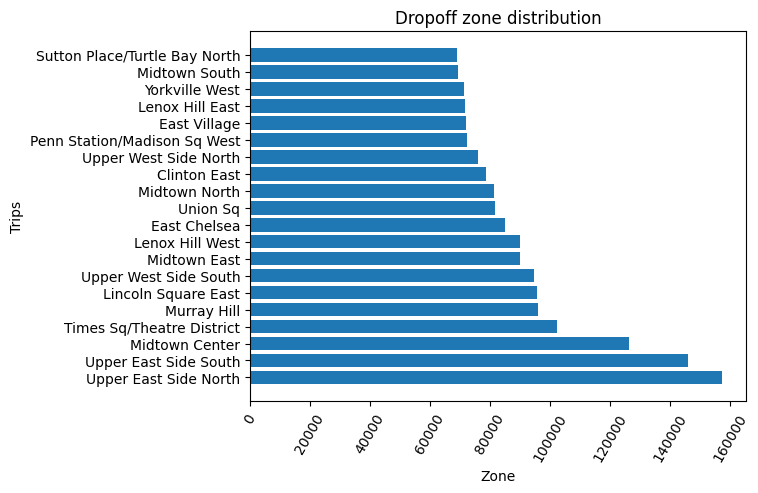

In [87]:
#common drop off zones

dropoff_common =  pd.read_parquet('../data/marts/mart_dropoff_common.parquet').reset_index().head(20)
taxi_zone = pd.read_csv('../data/raw/taxi_zone_lookup.csv')

dropoff_common = dropoff_common.merge(
    taxi_zone[['LocationID','Zone']],
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
).rename(columns = {'Zone':'pickup_zone'}).drop(columns=['LocationID'])

plt.Figure(figsize = (10,5))
plt.title('Dropoff zone distribution')

plt.barh(dropoff_common['pickup_zone'].astype(str),dropoff_common ['trip_count'])

plt.xlabel('Zone')
plt.ylabel('Trips')
plt.xticks(rotation = 60)
plt.show()

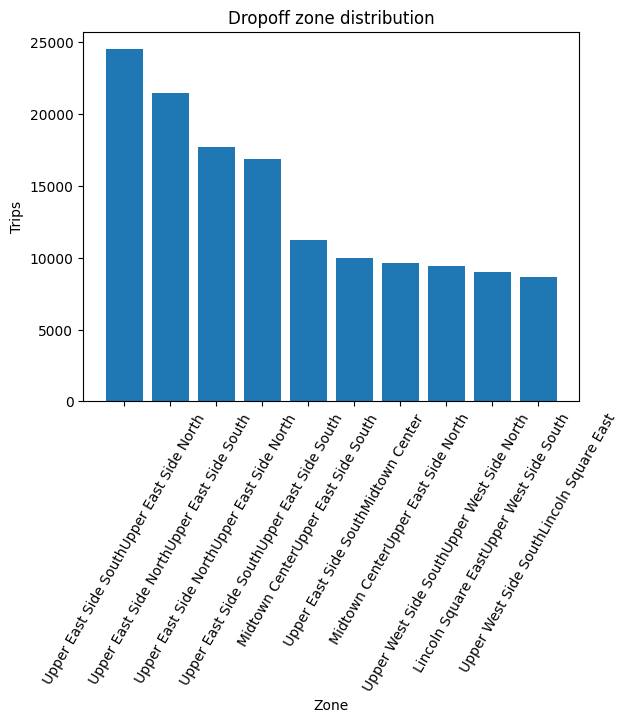

In [64]:
#Top pickup dropoff pair

pudo_pair = (
    df.groupby(['PULocationID','DOLocationID'])
    .agg(trip_count = ('tpep_pickup_datetime','count'))
    .sort_values('trip_count', ascending = False)
    .reset_index()
)

pudo_pair = pudo_pair.merge(
    taxi_zone[['LocationID','Zone']],
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
).rename(columns = {'Zone':'dropoff_zone'}).drop(columns=['LocationID'])

pudo_pair = pudo_pair.merge(
    taxi_zone[['LocationID','Zone']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
).rename(columns = {'Zone':'pickup_zone'}).drop(columns=['LocationID'])

pudo_pair['pair_name'] = pudo_pair['pickup_zone'] + pudo_pair['dropoff_zone']

top_10_pair = pudo_pair.head(10)
plt.Figure(figsize = (10,5))
plt.title('Dropoff zone distribution')

plt.bar(top_10_pair['pair_name'],top_10_pair ['trip_count'])

plt.xlabel('Zone')
plt.ylabel('Trips')
plt.xticks(rotation = 60)
plt.show()

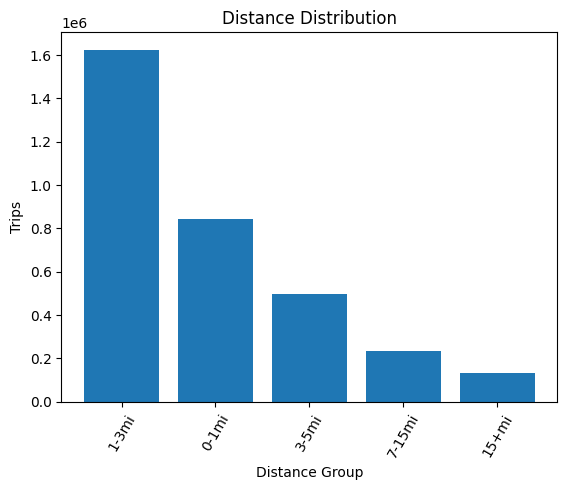

In [63]:
#Distance distribution

trip_distribution =  pd.read_parquet('../data/marts/mart_trip_distribution.parquet').reset_index()

plt.Figure(figsize = (10,5))
plt.title('Distance Distribution')

plt.bar(trip_distribution['distance_group'].astype(str),trip_distribution ['trip_count'])

plt.xlabel('Distance Group')
plt.ylabel('Trips')
plt.xticks(rotation = 60)
plt.show()

C:\Users\Loc Nguyen\AppData\Local\Temp\ipykernel_1148\2207919300.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('duration_group')


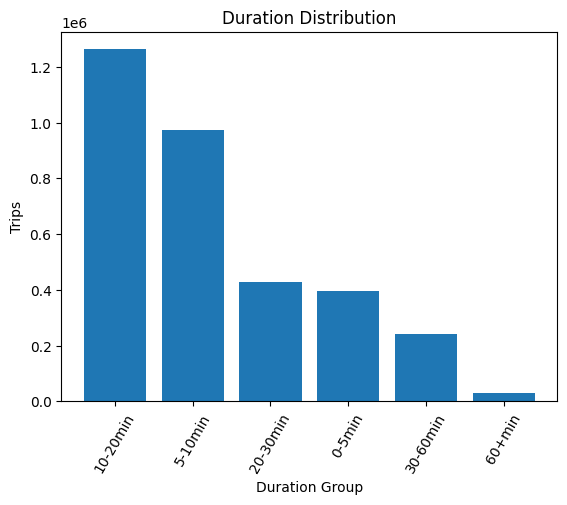

In [68]:
#Duration distribution

bins = [0,5,10,20,30,60,np.inf]
locals = ['0-5min','5-10min','10-20min','20-30min','30-60min','60+min']

df['duration_group'] = pd.cut(df['duration_mins'],bins = bins, labels = locals, right = False)

duration_distribution = (
    df.groupby('duration_group')
    .agg(
        total_passenger = ('passenger_count','sum'),
        trip_count = ('tpep_pickup_datetime','count'),
        avg_trip_distance =('trip_distance','mean'),
        revenue= ("total_amount","sum"),
        avg_tip_rate = ('tip_rate','mean'),
        avg_duration = ('duration_mins','mean')
    )
    .sort_values('trip_count', ascending = False)
    .reset_index()
)

duration_distribution['avg_tip_rate'] = duration_distribution['avg_tip_rate'] * 100

plt.Figure(figsize = (10,5))
plt.title('Duration Distribution')

plt.bar(duration_distribution['duration_group'].astype(str),duration_distribution ['trip_count'])

plt.xlabel('Duration Group')
plt.ylabel('Trips')
plt.xticks(rotation = 60)
plt.show()

C:\Users\Loc Nguyen\AppData\Local\Temp\ipykernel_1148\2641403881.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('fare_group')


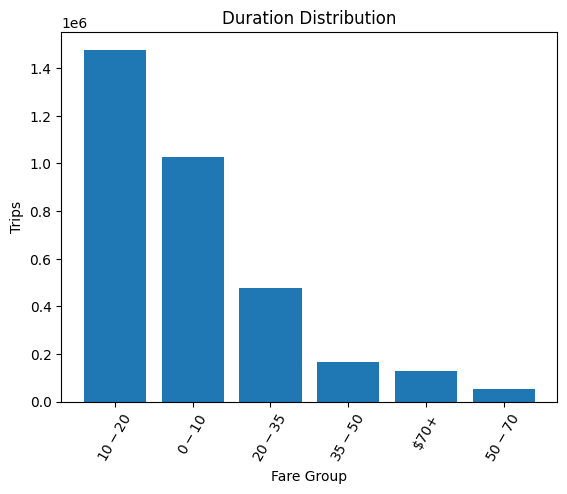

In [69]:
#Fare distribution

bins = [0,10,20,35,50,70,np.inf]
locals = ['$0-$10','$10-$20','$20-$35','$35-$50','$50-$70','$70+']

df['fare_group'] = pd.cut(df['fare_amount'],bins = bins, labels = locals, right = False)

fare_distribution = (
    df.groupby('fare_group')
    .agg(
        total_passenger = ('passenger_count','sum'),
        trip_count = ('tpep_pickup_datetime','count'),
        avg_trip_distance =('trip_distance','mean'),
        revenue= ("total_amount","sum"),
        avg_tip_rate = ('tip_rate','mean'),
        avg_duration = ('duration_mins','mean')
    )
    .sort_values('trip_count', ascending = False)
    .reset_index()
)

fare_distribution['avg_tip_rate'] = fare_distribution['avg_tip_rate'] * 100

plt.Figure(figsize = (10,5))
plt.title('Duration Distribution')

plt.bar(fare_distribution['fare_group'].astype(str),fare_distribution ['trip_count'])

plt.xlabel('Fare Group')
plt.ylabel('Trips')
plt.xticks(rotation = 60)
plt.show()

In [70]:
# Data statistic analytics

summary_stats = pd.DataFrame(
    {
        'Metric': ['Fare Amount ($)', 'Distance (mi)','Duration (min)'],
        'Mean': [
            df['fare_amount'].mean(),
            df['trip_distance'].mean(),
            df['duration_mins'].mean(),
        ],
        'Median': [
            df['fare_amount'].median(),
            df['trip_distance'].median(),
            df['duration_mins'].median(),
        ],
    }
)

summary_stats['Mean to Median Ratio'] = (
    summary_stats['Mean'] / summary_stats['Median']
)
display(summary_stats.round(2))

,Metric,Mean,Median,Mean to Median Ratio
0,Fare Amount ($),18.33,12.80,1.43
1,Distance (mi),5.39,1.67,3.23
2,Duration (min),15.05,11.67,1.29


"The mean fare is higher than the median fare due to right-skewness caused by long-distance airport trips and high-fare outliers. The median gives a more realistic representation of a standard city ride."

In [ ]:
# Percentiles (distribution boundaries)
percentile_levels = [0.1, 0.25, 0.5, 0.75, 0.9,0.95,0.99]

percentile_df = df[
    ['fare_amount','trip_distance','duration_mins','tip_rate']
].quantile(percentile_levels)

percentile_df.index = [f'{int(p*100)}th %ile' for p in percentile_levels]
display(percentile_df.round(2))

,fare_amount,trip_distance,duration_mins,tip_rate
10th %ile,6.5,0.60,4.62,0.00
25th %ile,8.6,0.99,7.27,0.00
50th %ile,12.8,1.67,11.67,0.24
75th %ile,19.8,3.09,18.32,0.30
90th %ile,35.9,7.70,27.60,0.36
95th %ile,54.1,11.89,36.35,0.41
99th %ile,73.7,19.51,59.18,0.53


"90% of trips are under 5 miles, but the 99th percentile jumps significantly. This indicates that extreme long-distance trips are a very tiny fraction of total volume, but contribute heavily to total revenue."

In [73]:
# Coorelations (Linear relationship)
correlations = df[
    ['trip_distance','duration_mins','fare_amount']
].corr()

display(correlations.round(3))

dist_fare_corr = df['trip_distance'].corr(df['fare_amount'])
dur_fare_corr = df['duration_mins'].corr(df['fare_amount'])

print(f'Distance vs. Fare correlation: {dist_fare_corr:.3f}')
print(f'Duration vs. Fare correlation: {dur_fare_corr:.3f}')

,trip_distance,duration_mins,fare_amount
trip_distance,1.000,0.003,0.000
duration_mins,0.003,1.000,0.012
fare_amount,0.000,0.012,1.000


Distance vs. Fare correlation: 0.000
Duration vs. Fare correlation: 0.012


"Trip distance shows a strong positive correlation with fare amount. Duration also correlates positively, though traffic delays can cause duration to inflate fares even on short-distance trips."

In [ ]:
#Group comparison by day type
df['is_weekend'] = df['pickup_dayofw'].isin([5,6])
df['day_type'] = np.where(df['is_weekend'],'Weekend','Weekday')

week_comparison = (
    df.groupby('day_type')
    .agg(
        total_trips=("fare_amount", "count"),
        avg_fare=("fare_amount", "mean"),
        median_fare=("fare_amount", "median"),
        avg_distance=("trip_distance", "mean"),
        avg_duration=("duration_mins", "mean"),
    )
    .reset_index()
)

display(week_comparison.round(2))

,day_type,total_trips,avg_fare,median_fare,avg_distance,avg_duration
0,Weekday,2490045,18.48,12.8,5.38,15.39
1,Weekend,840618,17.87,12.8,5.42,14.04


In [76]:
#Group comparison by credit card vs. cash tipping

tip_by_payment = (
    df.groupby('payment_type')
    .agg(
        total_trips=("fare_amount", "count"),
        avg_fare=("fare_amount", "mean"),
        median_fare=("fare_amount", "median"),
        avg_distance=("trip_distance", "mean"),
        avg_duration=("duration_mins", "mean"),
    )
    .reset_index()
)

display(tip_by_payment.round(3))

,payment_type,total_trips,avg_fare,median_fare,avg_distance,avg_duration
0,0,455209,18.161,15.75,19.291,15.398
1,1,2444372,18.009,12.10,3.196,15.027
2,2,376318,18.057,12.10,3.116,15.112
3,3,15693,16.797,8.60,2.438,11.153
4,4,39070,43.333,12.10,3.572,13.655
5,5,1,0.000,0.00,0.000,0.317


In [77]:
#Anomaly analysis
#Combine existing flags

mart_anomal = pd.read_parquet('../data/marts/mart_abnormals.parquet')

mart_anomal['flag_hard_rejected'] = (
    mart_anomal['flag_impossible_speed']
    | (mart_anomal['fare_amount'] <= 0)
    | (mart_anomal['trip_distance'] <= 0)
    | (mart_anomal['passenger_count'] == 0)
)

mart_anomal['flag_sus_retained'] = ~mart_anomal['flag_hard_rejected'] & (
    mart_anomal['flag_extreme_dist']
    | (mart_anomal['total_amount'] > 300)
    | (mart_anomal['fare_amount'] > 150)
)


In [78]:
#separate records into marts
mart_rejected_record = mart_anomal[mart_anomal['flag_hard_rejected']].copy()

clean_yellow = mart_anomal[~mart_anomal['flag_hard_rejected']].copy()

mart_anomalies = clean_yellow[ clean_yellow['flag_sus_retained']].copy()

In [80]:
dq_summary = pd.DataFrame(
    [
        {
            'Category': 'Impossible Speed (<0 or > 80mph)',
            'Flag Column': 'flag_impossible_speed',
            'type': 'Rejected',
            'Count': mart_anomal['flag_impossible_speed'].sum()
        },
        {
            "Category": "Extreme Distance (>= 50 miles)",
            "Flag Column": "flag_extreme_dist",
            "Type": "Suspicious (Retained)",
            "Count": mart_anomal["flag_extreme_dist"].sum(),
        },
    ]
)

total_rows = len(mart_anomal)
dq_summary['pct_of_total'] = ((dq_summary['Count'] / total_rows) * 100 ).map('{:.3f}%'.format)

display(dq_summary)

,Category,Flag Column,type,Count,Type,pct_of_total
0,Impossible Speed (<0 or > 80mph),flag_impossible_speed,Rejected,2181,NaN,85.630%
1,Extreme Distance (>= 50 miles),flag_extreme_dist,NaN,490,Suspicious (Retained),19.238%
